In [78]:
#imports
import os
import sys
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from google.cloud import bigquery
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [74]:
# root / path
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)

Project root: /home/dd4real2k/code/mlbh/GridZero


In [3]:
# Load Dataset from BigQuery

client = bigquery.Client(project="gridzero-489711")

query = """
SELECT *
FROM `gridzero-489711.merged_set.full_feature_engineered_data_test`
ORDER BY datetime
"""

df = client.query(query).to_dataframe()

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (148991, 31)


,datetime,temperature_2m_c,wind_speed_100m_ms,wind_gusts_10m_ms,cloud_cover_pct,shortwave_radiation_wm2,direct_radiation_wm2,diffuse_radiation_wm2,pressure_msl_hpa,precipitation_mm,...,carbon_intensity_gco2_kwh,hour_sin,hour_cos,dow_sin,dow_cos,doy_sin,doy_cos,carbon_lag_48,carbon_lag_336,carbon_lag_17520
0,2017-09-12 00:00:00+00:00,11.6,31.0,28.1,4.0,0.0,0.0,0.0,1001.2,0.0,...,142.0,0.000000,1.000000,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
1,2017-09-12 00:30:00+00:00,11.6,31.0,28.1,4.0,0.0,0.0,0.0,1001.2,0.0,...,140.0,0.000000,1.000000,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
2,2017-09-12 01:00:00+00:00,11.2,30.3,27.0,5.0,0.0,0.0,0.0,1001.9,0.0,...,139.0,0.258819,0.965926,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
3,2017-09-12 01:30:00+00:00,11.2,30.3,27.0,5.0,0.0,0.0,0.0,1001.9,0.0,...,137.0,0.258819,0.965926,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
4,2017-09-12 02:00:00+00:00,10.9,29.6,25.2,7.0,0.0,0.0,0.0,1002.4,0.0,...,132.0,0.500000,0.866025,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN


In [75]:
# convert datetime and sort

df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

print(df["datetime"].min(), "to", df["datetime"].max())
df.head()

2017-09-22 12:00:00+00:00 to 2026-03-12 23:00:00+00:00


,datetime,temperature_2m_c,wind_speed_100m_ms,wind_gusts_10m_ms,cloud_cover_pct,shortwave_radiation_wm2,direct_radiation_wm2,diffuse_radiation_wm2,pressure_msl_hpa,precipitation_mm,...,hour_cos,dow_sin,dow_cos,doy_sin,doy_cos,carbon_lag_48,carbon_lag_336,carbon_lag_17520,carbon_roll_24h,carbon_roll_168h
0,2017-09-22 12:00:00+00:00,16.5,15.6,28.8,78.0,580.0,444.0,136.0,1021.4,0.0,...,-1.000000,-0.433884,-0.900969,-0.988678,-0.150055,285.0,270.0,NaN,254.791667,287.553571
1,2017-09-22 12:30:00+00:00,16.5,15.6,28.8,78.0,580.0,444.0,136.0,1021.4,0.0,...,-1.000000,-0.433884,-0.900969,-0.988678,-0.150055,282.0,249.0,NaN,251.708333,287.035714
2,2017-09-22 13:00:00+00:00,17.1,19.5,27.7,94.0,452.0,258.0,194.0,1021.2,0.0,...,-0.965926,-0.433884,-0.900969,-0.988678,-0.150055,280.0,262.0,NaN,248.666667,286.494048
3,2017-09-22 13:30:00+00:00,17.1,19.5,27.7,94.0,452.0,258.0,194.0,1021.2,0.0,...,-0.965926,-0.433884,-0.900969,-0.988678,-0.150055,280.0,251.0,NaN,245.708333,285.982143
4,2017-09-22 14:00:00+00:00,17.4,20.1,29.2,100.0,410.0,215.0,195.0,1020.9,0.0,...,-0.866025,-0.433884,-0.900969,-0.988678,-0.150055,277.0,257.0,NaN,243.041667,285.494048


In [76]:
# Lag feature

lag_features = [
    "carbon_lag_48",
    "carbon_lag_336"
]

print("Missing before fill:")
print(df[lag_features].isnull().sum())

df[lag_features] = df[lag_features].ffill()

print("\nMissing after fill:")
print(df[lag_features].isnull().sum())

print("\nRows before drop:", len(df))
df = df.dropna(subset=lag_features).reset_index(drop=True)
print("Rows after drop:", len(df))

Missing before fill:
carbon_lag_48     0
carbon_lag_336    0
dtype: int64

Missing after fill:
carbon_lag_48     0
carbon_lag_336    0
dtype: int64

Rows before drop: 148487
Rows after drop: 148487


In [77]:
# Create rolling features and drop rolling NaNs

df["carbon_roll_24h"] = df["carbon_intensity_gco2_kwh"].shift(1).rolling(24).mean()
df["carbon_roll_168h"] = df["carbon_intensity_gco2_kwh"].shift(1).rolling(168).mean()

print("Rows before dropping rolling NaNs:", len(df))

df = df.dropna(subset=["carbon_roll_24h", "carbon_roll_168h"]).reset_index(drop=True)

print("Rows after dropping rolling NaNs:", len(df))

df[["carbon_roll_24h", "carbon_roll_168h"]].head()

Rows before dropping rolling NaNs: 148487
Rows after dropping rolling NaNs: 148319


,carbon_roll_24h,carbon_roll_168h
0,340.833333,250.339286
1,339.958333,250.964286
2,339.208333,251.607143
3,338.416667,252.238095
4,337.541667,252.833333


In [79]:
# Target and Features

X = df[features].copy()
y = df[target].copy()

print("", X.isnull().sum().sum())
print("", y.isnull().sum())

 0
 0


In [54]:
target = "carbon_intensity_gco2_kwh"

features = [
    "temperature_2m_c",
    "wind_speed_100m_ms",
    "wind_gusts_10m_ms",
    "cloud_cover_pct",
    "shortwave_radiation_wm2",
    "direct_radiation_wm2",
    "diffuse_radiation_wm2",
    "pressure_msl_hpa",
    "precipitation_mm",
    "biomass",
    "fossil_gas",
    "fossil_hard_coal",
    "hydro_pumped_storage",
    "hydro_run_of_river_and_poundage",
    "nuclear",
    "other",
    "solar",
    "wind_offshore",
    "wind_onshore",
    "totaloutput_mw",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "doy_sin",
    "doy_cos",
    "carbon_lag_48",
    "carbon_lag_336",
    "carbon_roll_24h",
    "carbon_roll_168h"
]

X = df[features].copy()
y = df[target].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (148487, 30)
Target shape: (148487,)


In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    df[features],
    df[target],
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (118655, 30) (118655,)
Test shape: (29664, 30) (29664,)


In [57]:
model = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=12,
    num_leaves=50,
    min_child_samples=15,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("LightGBM model training completed")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018521 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6320
[LightGBM] [Info] Number of data points in the train set: 118924, number of used features: 30
[LightGBM] [Info] Start training from score 180.143126
LightGBM model training completed


In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    df[features],
    df[target],
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (118789, 30) (118789,)
Test shape: (29698, 30) (29698,)


In [59]:
predictions = model.predict(X_test)

predictions[:10]

array([ 93.32203596, 218.76093854, 239.504569  , 208.61865433,
       275.44880482, 220.86973286,  79.34418099, 102.77988704,
       110.78713258, 178.83902142])

In [60]:
mae = mean_absolute_error(y_test, predictions)
rmse = mean_squared_error(y_test, predictions) ** 0.5
r2 = r2_score(y_test, predictions)

print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))

MAE : 6.7324
RMSE: 8.8264
R²  : 0.9864


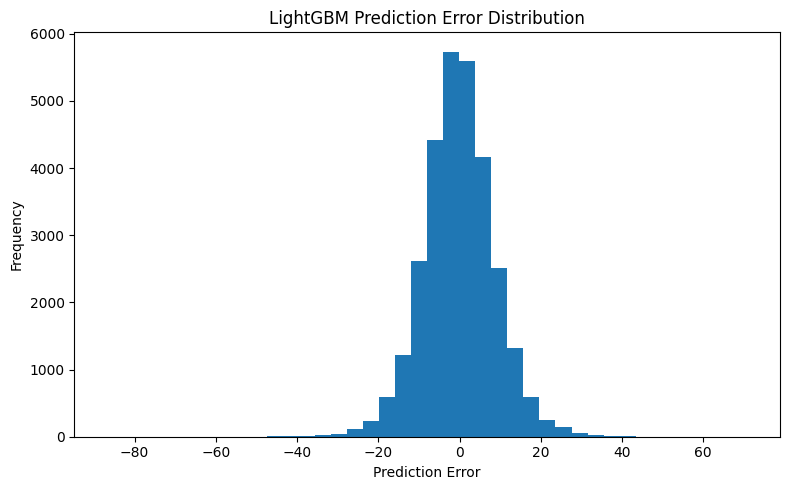

In [66]:
errors = y_test - predictions

plt.figure(figsize=(8, 5))
plt.hist(errors, bins=40)

plt.title("LightGBM Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

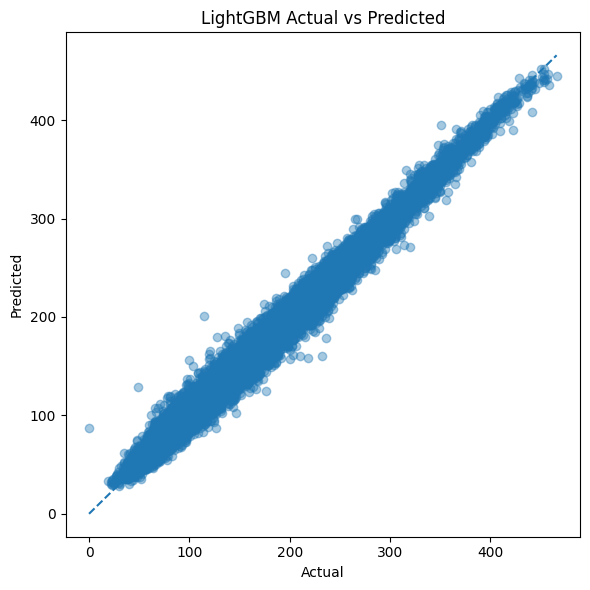

In [67]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, predictions, alpha=0.4)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("LightGBM Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.tight_layout()
plt.show()

In [68]:
importance = pd.Series(
    model.feature_importances_,
    index=X_test.columns
).sort_values(ascending=False)

importance.head(15)

doy_sin             2614
carbon_roll_24h     2554
doy_cos             2516
nuclear             2502
fossil_gas          2452
fossil_hard_coal    2156
wind_offshore       2132
wind_onshore        2097
pressure_msl_hpa    1772
carbon_roll_168h    1704
other               1670
biomass             1527
solar               1474
hour_sin            1467
carbon_lag_336      1190
dtype: int32

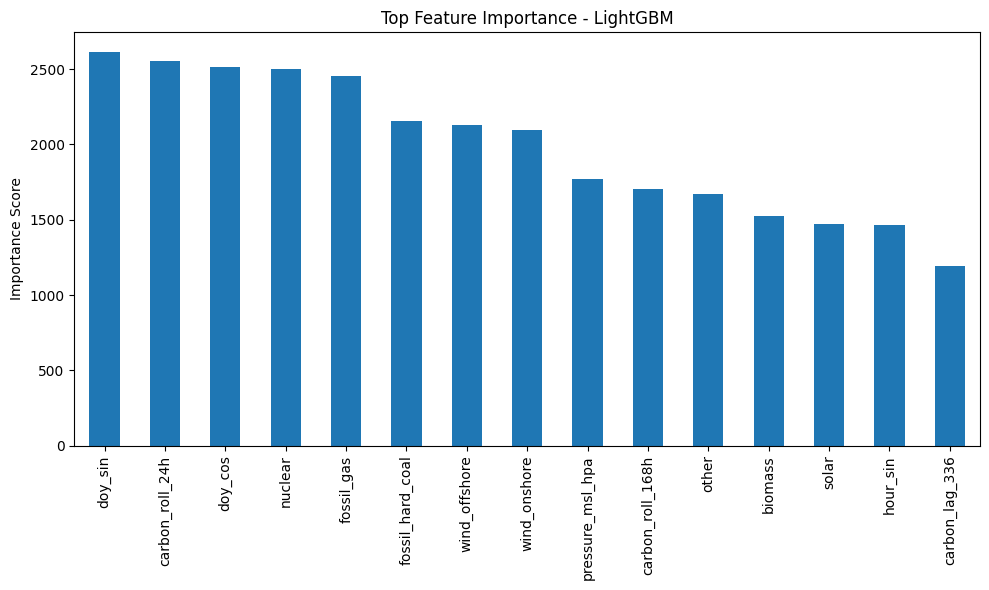

In [69]:
plt.figure(figsize=(10, 6))
importance.head(15).plot(kind="bar")

plt.title("Top Feature Importance - LightGBM")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

In [71]:
os.makedirs("../models", exist_ok=True)

model_path = "../models/lightgbm_model.joblib"
joblib.dump(model, model_path)

print("Model saved to:", model_path)

Model saved to: ../models/lightgbm_model.joblib


In [72]:
summary = pd.DataFrame({
    "model": ["LightGBM"],
    "target": [target],
    "n_features": [len(features)],
    "train_rows": [len(X_train)],
    "test_rows": [len(X_test)],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2]
})

summary

,model,target,n_features,train_rows,test_rows,MAE,RMSE,R2
0,LightGBM,carbon_intensity_gco2_kwh,30,118789,29698,6.732369,8.826423,0.986395
